In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('seaborn-whitegrid')
%matplotlib inline

import keras

In [2]:
target_var = ['RUL']
index_columns_names =  ['UnitNumber','Cycle']
op_settings_columns = ['Op_set'+str(i) for i in range(1,4)]
sensor_columns =['Sensor'+str(i) for i in range(1,22)]
column_names = index_columns_names + op_settings_columns + sensor_columns
print(column_names)

['UnitNumber', 'Cycle', 'Op_set1', 'Op_set2', 'Op_set3', 'Sensor1', 'Sensor2', 'Sensor3', 'Sensor4', 'Sensor5', 'Sensor6', 'Sensor7', 'Sensor8', 'Sensor9', 'Sensor10', 'Sensor11', 'Sensor12', 'Sensor13', 'Sensor14', 'Sensor15', 'Sensor16', 'Sensor17', 'Sensor18', 'Sensor19', 'Sensor20', 'Sensor21']


In [3]:
train= pd.read_csv('train_FD001.txt', sep=" ", header=None)
test = pd.read_csv('test_FD001.txt', sep=" ", header=None)
#print(train.info())
#print(test.info())

In [4]:
# drop kolom null
train.drop(train.columns[[26, 27]], axis=1, inplace=True)
test.drop(test.columns[[26, 27]], axis=1, inplace=True)

In [5]:
train.columns = column_names
test.columns = column_names

In [6]:
train.head()

,UnitNumber,Cycle,Op_set1,Op_set2,Op_set3,Sensor1,Sensor2,Sensor3,Sensor4,Sensor5,...,Sensor12,Sensor13,Sensor14,Sensor15,Sensor16,Sensor17,Sensor18,Sensor19,Sensor20,Sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [7]:
"""plt.figure(figsize=(10,25))
ax=train.groupby('UnitNumber')['Cycle'].max().plot(kind='barh',width=0.8, stacked=True,align='center',rot=0)
plt.title('Engines Life Time',fontweight='bold',size=35)
plt.xlabel('Cycle Time',fontweight='bold',size=30)
plt.xticks(size=25)
plt.ylabel('Unit Number',fontweight='bold',size=30)
plt.yticks(size=25)
plt.grid(True)
plt.tight_layout(True)
plt.show()"""

"plt.figure(figsize=(10,25))\nax=train.groupby('UnitNumber')['Cycle'].max().plot(kind='barh',width=0.8, stacked=True,align='center',rot=0)\nplt.title('Engines Life Time',fontweight='bold',size=35)\nplt.xlabel('Cycle Time',fontweight='bold',size=30)\nplt.xticks(size=25)\nplt.ylabel('Unit Number',fontweight='bold',size=30)\nplt.yticks(size=25)\nplt.grid(True)\nplt.tight_layout(True)\nplt.show()"

In [8]:
train['RUL'] = train.groupby('UnitNumber')['Cycle'].transform(max)-train['Cycle']
train

,UnitNumber,Cycle,Op_set1,Op_set2,Op_set3,Sensor1,Sensor2,Sensor3,Sensor4,Sensor5,...,Sensor13,Sensor14,Sensor15,Sensor16,Sensor17,Sensor18,Sensor19,Sensor20,Sensor21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1


In [9]:
"""explore = sns.PairGrid(data=train.query('UnitNumber < 15') ,
                 x_vars=target_var,
                 y_vars=sensor_columns + op_settings_columns,
                 hue='UnitNumber', height=3, aspect=2.5)
explore = explore.map(plt.scatter, alpha=0.5)
explore = explore.set(xlim=(400,0))
explore = explore.add_legend()"""

"explore = sns.PairGrid(data=train.query('UnitNumber < 15') ,\n                 x_vars=target_var,\n                 y_vars=sensor_columns + op_settings_columns,\n                 hue='UnitNumber', height=3, aspect=2.5)\nexplore = explore.map(plt.scatter, alpha=0.5)\nexplore = explore.set(xlim=(400,0))\nexplore = explore.add_legend()"

In [10]:
# drop nilai konstan
#train = train.drop(['Sensor1','Sensor5','Sensor6','Sensor10','Sensor16','Sensor18','Sensor19','Op_set3'], axis=1)

In [11]:
"""g = sns.pairplot(data=train.query('UnitNumber < 15'),
                 x_vars=['Op_set1','Op_set2'],
                 y_vars=['Sensor2', 'Sensor3', 'Sensor4', 'Sensor7', 'Sensor8', 'Sensor9', 'Sensor11', 'Sensor12', 'Sensor13', 'Sensor14', 'Sensor15', 'Sensor17', 'Sensor20', 'Sensor21'],
                 hue='UnitNumber', aspect=1)"""

"g = sns.pairplot(data=train.query('UnitNumber < 15'),\n                 x_vars=['Op_set1','Op_set2'],\n                 y_vars=['Sensor2', 'Sensor3', 'Sensor4', 'Sensor7', 'Sensor8', 'Sensor9', 'Sensor11', 'Sensor12', 'Sensor13', 'Sensor14', 'Sensor15', 'Sensor17', 'Sensor20', 'Sensor21'],\n                 hue='UnitNumber', aspect=1)"

In [12]:
train = train.drop(['UnitNumber','Cycle'], axis=1)
test = test.drop(['UnitNumber','Cycle'],#'Sensor1','Sensor5','Sensor6','Sensor10','Sensor16','Sensor18','Sensor19','Op_set3'], 
                  axis=1)

In [13]:
"""plt.subplots(figsize=(17, 6))
sns.heatmap(train.corr(), annot=True, cmap="RdYlGn")
plt.show()"""

'plt.subplots(figsize=(17, 6))\nsns.heatmap(train.corr(), annot=True, cmap="RdYlGn")\nplt.show()'

In [14]:
#input
X = train.drop(['RUL'], axis=1)
#target
y = train['RUL']

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=3)

print('X_train shape : ',X_train.shape)
print('X_test shape : ',X_test.shape)
print('y_train shape : ',y_train.shape)
print('y_test shape : ',y_test.shape)

X_train shape :  (16504, 24)
X_test shape :  (4127, 24)
y_train shape :  (16504,)
y_test shape :  (4127,)


In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

rf = RandomForestRegressor()
rf.fit(X_train, y_train)
train_pred = rf.predict(X_train)
test_pred = rf.predict(X_test)

print('Train Mean Absolute Error:', mean_absolute_error(y_train, train_pred))
print('Train Root Mean Squared Error:',np.sqrt(mean_squared_error(y_train, train_pred)))
print('Test Mean Absolute Error:', mean_absolute_error(y_test, test_pred))
print('Test Root Mean Squared Error:',np.sqrt(mean_squared_error(y_test, test_pred)))
print(rf.score(X_train, y_train))
print(rf.score(X_test, y_test))

Train Mean Absolute Error: 10.980281749878818
Train Root Mean Squared Error: 15.600106900097643
Test Mean Absolute Error: 29.570986188514656
Test Root Mean Squared Error: 41.43870510799512
0.9488039810946306
0.6351952573204873


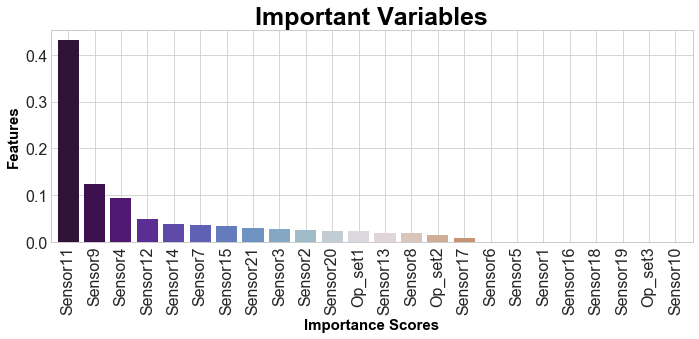

In [17]:
colors = [plt.cm.twilight_shifted(i/float(len(X.columns)-1)) for i in range(len(X.columns))]
columns_X_train=X.columns.tolist()
X_train=pd.DataFrame(X_train)
X_train.set_axis(columns_X_train, axis=1, inplace=True)
feat_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
plt.figure(figsize=(10,5))
plt.rcParams.update({'font.size': 16})
plt.title('Important Variables',color='black',fontweight='bold',size=25)
feat_importances.nlargest(len(X.columns)).plot(kind='bar', color=colors, width=0.8, align='center')
plt.ylabel('Features',color='black',fontweight='bold',size=15)
plt.xlabel('Importance Scores',color='black',fontweight='bold',size=15)
plt.tight_layout()
plt.grid(True)
plt.show()

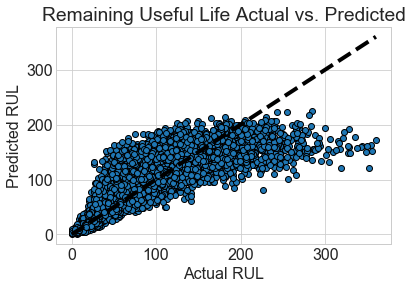

In [18]:
fig, ax = plt.subplots()
ax.scatter(y_test, test_pred, edgecolors=(0, 0, 0))
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_xlabel('Actual RUL')
ax.set_ylabel('Predicted RUL')
ax.set_title('Remaining Useful Life Actual vs. Predicted')
plt.show()

In [19]:
import xgboost as xgb

xgreg = xgb.XGBRegressor()
xgreg.fit(X_train, y_train)
train_pred = xgreg.predict(X_train)
test_pred = xgreg.predict(X_test)

print('Train Mean Absolute Error:', mean_absolute_error(y_train, train_pred))
print('Train Root Mean Squared Error:',np.sqrt(mean_squared_error(y_train, train_pred)))
print('Test Mean Absolute Error:', mean_absolute_error(y_test, test_pred))
print('Test Root Mean Squared Error:',np.sqrt(mean_squared_error(y_test, test_pred)))
print(xgreg.score(X_train, y_train))
print(xgreg.score(X_test, y_test))

Train Mean Absolute Error: 18.930230239687024
Train Root Mean Squared Error: 26.82684266680819
Test Mean Absolute Error: 30.65443430352448
Test Root Mean Squared Error: 42.94429097532214
0.8486019900996116
0.6082049024569303


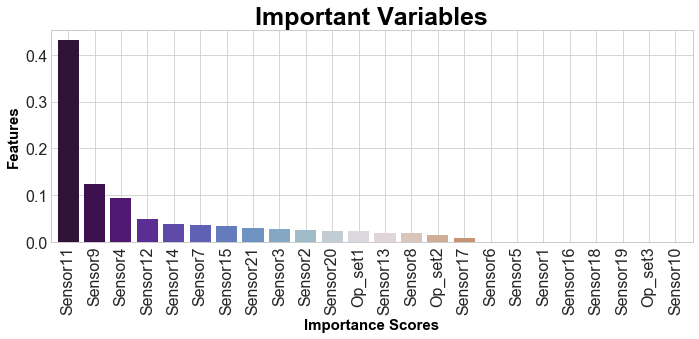

In [20]:
colors = [plt.cm.twilight_shifted(i/float(len(X.columns)-1)) for i in range(len(X.columns))]
columns_X_train=X.columns.tolist()
X_train=pd.DataFrame(X_train)
X_train.set_axis(columns_X_train, axis=1, inplace=True)
feat_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
plt.figure(figsize=(10,5))
plt.rcParams.update({'font.size': 16})
plt.title('Important Variables',color='black',fontweight='bold',size=25)
feat_importances.nlargest(len(X.columns)).plot(kind='bar', color=colors, width=0.8, align='center')
plt.ylabel('Features',color='black',fontweight='bold',size=15)
plt.xlabel('Importance Scores',color='black',fontweight='bold',size=15)
plt.tight_layout()
plt.grid(True)
plt.show()

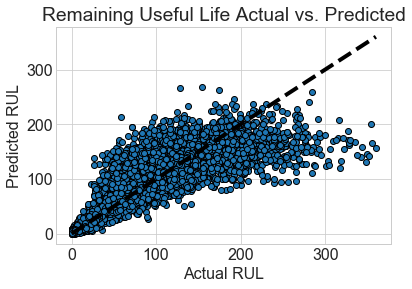

In [21]:
fig, ax = plt.subplots()
ax.scatter(y_test, test_pred, edgecolors=(0, 0, 0))
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_xlabel('Actual RUL')
ax.set_ylabel('Predicted RUL')
ax.set_title('Remaining Useful Life Actual vs. Predicted')
plt.show()

In [22]:
from lightgbm import LGBMRegressor

lgreg = LGBMRegressor()
lgreg.fit(X_train, y_train)
train_pred = lgreg.predict(X_train)
test_pred = lgreg.predict(X_test)

print('Train Mean Absolute Error:', mean_absolute_error(y_train, train_pred))
print('Train Root Mean Squared Error:',np.sqrt(mean_squared_error(y_train, train_pred)))
print('Test Mean Absolute Error:', mean_absolute_error(y_test, test_pred))
print('Test Root Mean Squared Error:',np.sqrt(mean_squared_error(y_test, test_pred)))
print(lgreg.score(X_train, y_train))
print(lgreg.score(X_test, y_test))

Train Mean Absolute Error: 25.267000549274087
Train Root Mean Squared Error: 35.543470581077024
Test Mean Absolute Error: 29.55101583391363
Test Root Mean Squared Error: 41.29931094256611
0.7342332136394174
0.6376454363740065


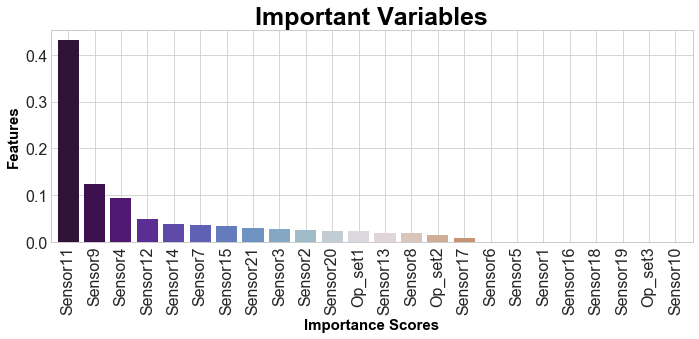

In [23]:
colors = [plt.cm.twilight_shifted(i/float(len(X.columns)-1)) for i in range(len(X.columns))]
columns_X_train=X.columns.tolist()
X_train=pd.DataFrame(X_train)
X_train.set_axis(columns_X_train, axis=1, inplace=True)
feat_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
plt.figure(figsize=(10,5))
plt.rcParams.update({'font.size': 16})
plt.title('Important Variables',color='black',fontweight='bold',size=25)
feat_importances.nlargest(len(X.columns)).plot(kind='bar', color=colors, width=0.8, align='center')
plt.ylabel('Features',color='black',fontweight='bold',size=15)
plt.xlabel('Importance Scores',color='black',fontweight='bold',size=15)
plt.tight_layout()
plt.grid(True)
plt.show()

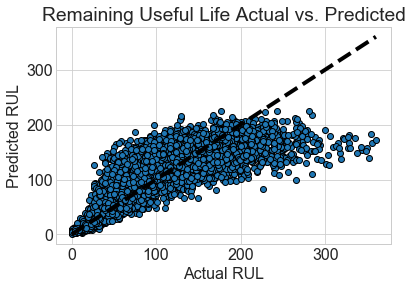

In [24]:
fig, ax = plt.subplots()
ax.scatter(y_test, test_pred, edgecolors=(0, 0, 0))
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_xlabel('Actual RUL')
ax.set_ylabel('Predicted RUL')
ax.set_title('Remaining Useful Life Actual vs. Predicted')
plt.show()